# Effective Potential of an Abelian Higgs Model

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from AbelianHiggs_Model import Abelian_Model

def Lagrangian_Parameters(v, mphi, mA):
    mu = mphi/np.sqrt(2)
    l  = mu**2/v**2
    g  = mA/v
    return mu, l, g

In [3]:
v, mphi, mA = 250, 60, 200

mu, l, g = Lagrangian_Parameters(v, mphi, mA)

model = Abelian_Model(l, mu, g)

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), 0.0).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v)/v * 100:.3f}%")

Numerical vev (Vtot, T=0): 250.000 GeV
CW shift: 0.000%


## $V_0$ vs $V_{eff}$

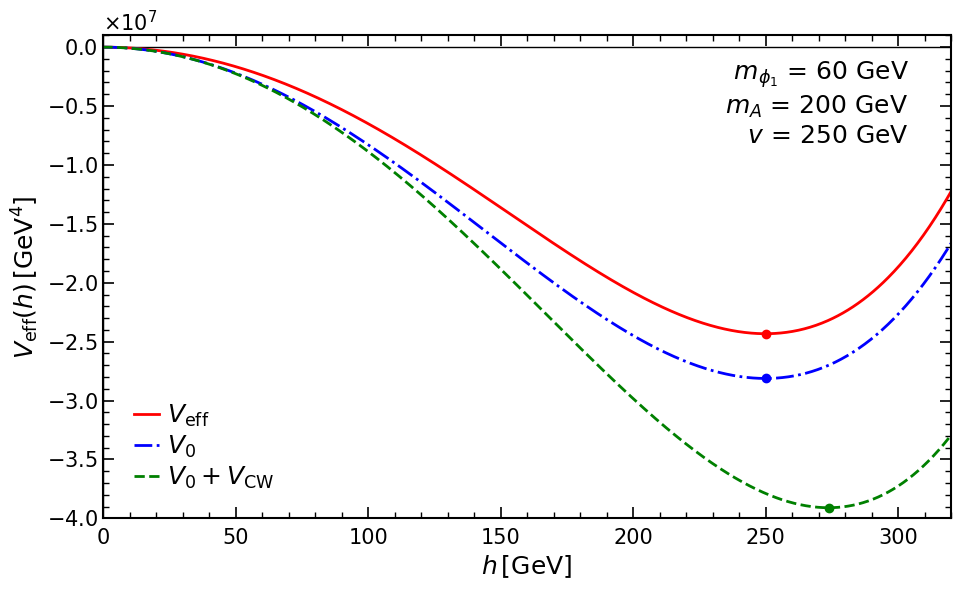

In [23]:
phi_vals = np.linspace(-25, 450, 1500)
X        = phi_vals[:, np.newaxis]

VTL   = model.V0(X)
Veff  = model.Vtot(X, 0.0)
VnoCT  = model.Vtot_no_CT(X, 0.0)
VTL0   = model.V0(np.array([[0.0]]))
Veff0  = model.Vtot(np.array([[0.0]]), 0.0)
VnoCT0 = model.Vtot_no_CT(np.array([[0.0]]), 0.0)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, Veff-Veff0, label=r'$V_{\mathrm{eff}}$', color='r', lw=2, ls='-')
ax.plot(phi_vals, VTL-VTL0, label=r'$V_0$', color='b', lw=2, ls='-.')
ax.plot(phi_vals, VnoCT-VnoCT0, label=r'$V_0+V_\mathrm{CW}$', color='g', lw=2, ls='--')

r = np.array(Veff-Veff0)
b = np.array(VTL-VTL0)
g = np.array(VnoCT-VnoCT0)
colors = ['r', 'b', 'g']
mask = (phi_vals>0)

for i, ar in enumerate([r, b, g]):
    ar_masked = ar[mask]
    x_masked = phi_vals[mask]
    id = np.argmin(ar_masked)
    ax.plot(x_masked[id], ar_masked[id], marker='o', color=colors[i], ms=6)

ax.set_xlim(0, 320)
ax.set_ylim(-4e7, 0.1e7)

ax.set_xlabel(r'$h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(h) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = rf'  $m_{{\phi_1}}$ = {mphi:.0f} GeV' '\n' rf'$m_A$ = {mA:.0f} GeV' '\n' rf'     $v$ = {v:.0f} GeV'
ax.text(0.95, 0.95, annotation, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0))

plt.tight_layout()
plt.savefig(f"AHM_Veff_Presentation.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Radiative Symmetry Breaking

In [3]:
def Radiative_Veff(phi, l, g, mu):
    mask = phi**2 > 0
    safe_mA = np.where(mask, g**2*phi**2, 1.0)
    safe_m1 = np.where(mask, 3*l*phi**2, 1.0)
    safe_m2 = np.where(mask, l*phi**2, 1.0)

    V0   = l/4*phi**4
    V1gb = 3/(64*np.pi**2)*(g**2*phi**2)**2*(np.log((safe_mA)/(mu**2))-5/6)
    V1ph = 1/(64*np.pi**2)*(3*l*phi**2)**2*(np.log((safe_m1)/(mu**2))-3/2)
    V1ci = 1/(64*np.pi**2)*(l*phi**2)**2*(np.log((safe_m2)/(mu**2))-3/2)

    return np.where(mask, V0+V1gb+V1ph+V1ci, V0)

def Radiative_V0(phi, l):
    V0   = l/4*phi**4
    return V0

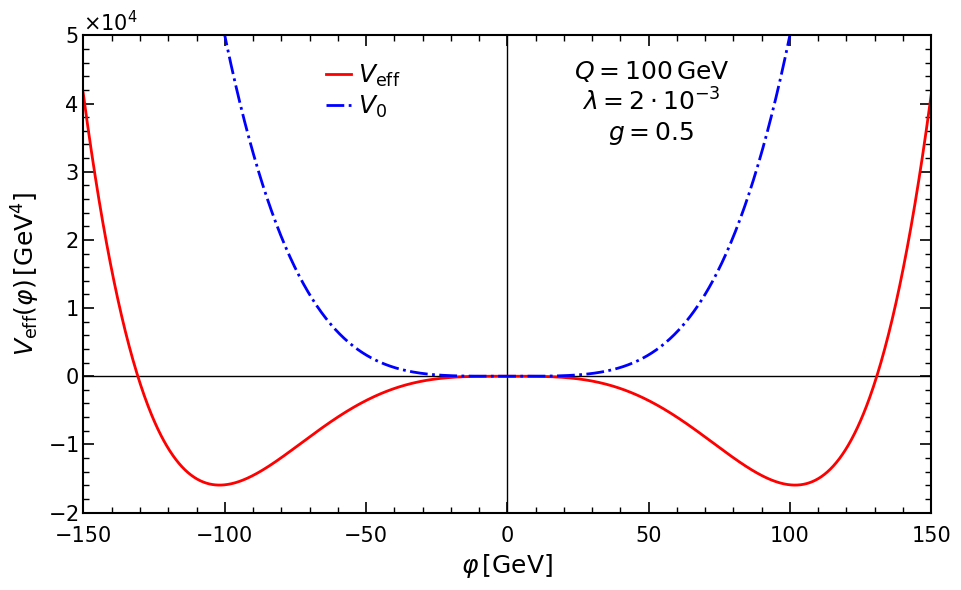

In [3]:
phi = np.linspace(-200,200,1500)
l = 2e-3
g = 0.5
mu = 100

V0 = Radiative_V0(phi, l)
Veff = Radiative_Veff(phi, l, g, mu)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi, Veff, label=r'$V_{\mathrm{eff}}$', color='r', lw=2, ls='-')
ax.plot(phi, V0, label=r'$V_0$', color='b', lw=2, ls='-.')

ax.set_xlim(-150, 150)
ax.set_ylim(-2e4, 5e4)

ax.set_xlabel(r'$\varphi \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=10)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper center", bbox_to_anchor=(0.33, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = r'$Q = 100 \, \mathrm{GeV}$' '\n' r'$\lambda = 2 \cdot 10^{-3}$' '\n' r'$g=0.5$'
ax.text(0.67, 0.95, annotation, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', horizontalalignment='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0))

plt.tight_layout()
plt.savefig(f"AHM_RSB_Veff.pdf", format="pdf", bbox_inches="tight")
plt.show()

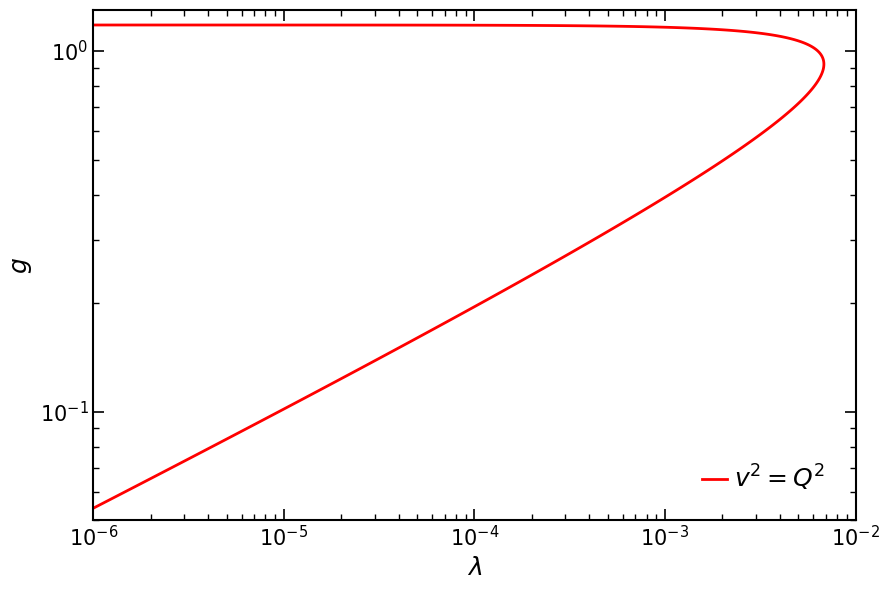

In [12]:
def vev_contour(l, g):
    return (g**4 + 10*l**2 - 16*np.pi**2*l - 3*g**4*np.log(g**2) - 9*l**2*np.log(3) - 10*l**2*np.log(l))

l = np.geomspace(1e-6, 1e-2, 500)
g = np.geomspace(0.05, 1.3, 500)

X, Y = np.meshgrid(l,g)
Z = vev_contour(X, Y)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contour(X, Y, Z, levels=[0], colors='r', linewidths=2)

ax.set_xlabel(r'$\lambda$', fontsize=18)
ax.set_ylabel(r'$g$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_xscale('log')
ax.set_yscale('log')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

handles_list = [mlines.Line2D([], [], color='r', linestyle='-', linewidth=2, alpha=1, label=r"$v^2=Q^2$"),]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"AHM_RSB_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [115]:
np.insert(np.linspace(0.2, 2, 10), 0, 0.0)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ])

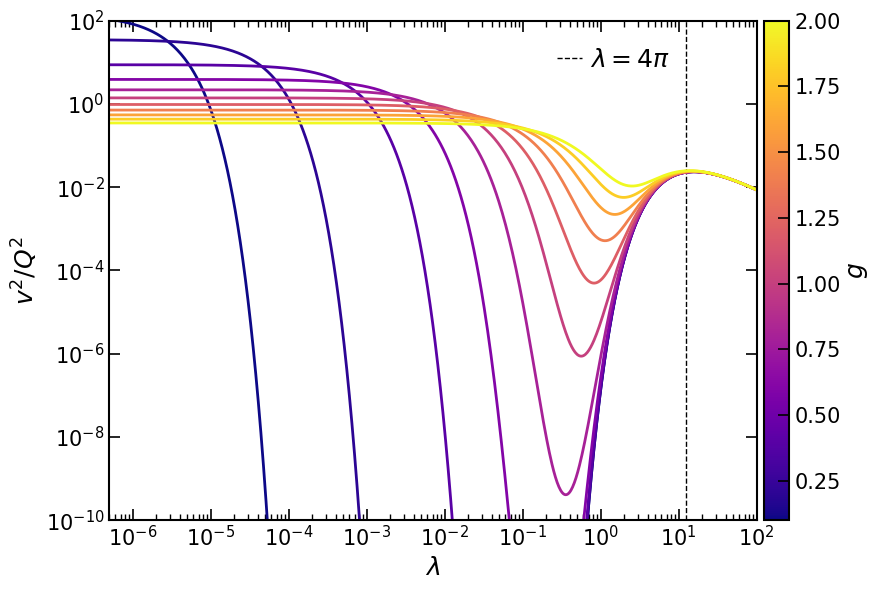

In [117]:
l = np.geomspace(1e-7, 1e4, 1000)
g_list = np.insert(np.linspace(0.2, 2, 10), 0, 0.1)

def vev_position(l,g):
    num = g**4 + 10*l**2 - 16*np.pi**2*l - 3*g**4*np.log(g**2) - 9*l**2*np.log(3) - 10*l**2*np.log(l)
    den = 3*g**4 + 10*l**2
    return np.exp(num/den)

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=g_list.min(), vmax=g_list.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))
ax.axvline(4*np.pi, color='k', lw=1, ls='--')

for g in g_list:
    vev = vev_position(l, g)
    color = cmap(norm(g))
    ax.plot(l, vev, color=color, lw=2)

ax.set_xlim(5e-7, 1e2)
ax.set_ylim(1e-10, 100)

ax.set_xlabel(r'$\lambda$', fontsize=18)
ax.set_ylabel(r'$v^2/Q^2$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_xscale('log')
ax.set_yscale('log')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$g$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

handles_list = [mlines.Line2D([], [], color='k', linestyle='--', linewidth=1, alpha=1, label=r"$ \lambda=4 \pi$"),]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.9, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"AHM_RSB_vev.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Thermal Field Theory

In [4]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [250.00000175] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
...............................................................................................................................................................
Tracing phase starting at x = [-1.55761719e-06] ; t = 121.56019359859606
Tracing minimum down
traceMinimum t0 = 121.56
.................................
Tracing minimum up
traceMinimum t0 = 121.56
............
Tc = 116.6012 GeV  |  xi_c = 1.54


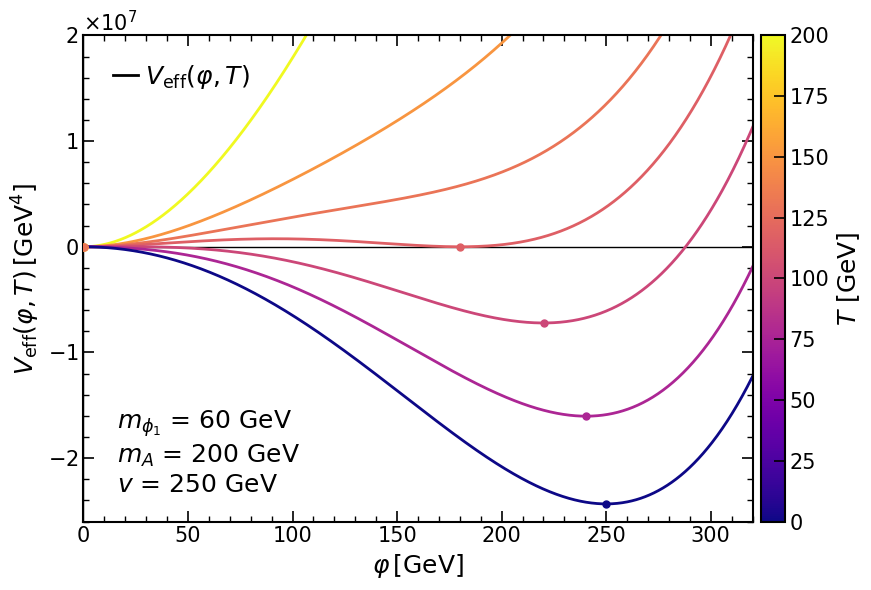

In [11]:
phi_vals = np.linspace(-50, 350, 1500)
X        = phi_vals[:, np.newaxis]
T_vals   = np.array([200.    , 150.    , 130.    , 116.6012, 100.    ,  77.    ,
         0.    ])

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
        color = cmap(norm(T))
        Veff  = model.Vtot(X, T)
        Veff0  = model.Vtot(np.array([[0.0]]), T)
        ax.plot(phi_vals, Veff-Veff0, label=r'$V_{\mathrm{eff}}(\varphi , T)$', color=color, lw=2, ls='-')

        mask = phi_vals > 0
        idx  = np.argmin(Veff[mask])
        phi_min = phi_vals[mask][idx]
        V_min   = Veff[mask][idx]
        ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5, zorder=10)


ax.set_xlim(0, 320)
ax.set_ylim(-2.6e7, 2e7)

ax.set_xlabel(r'$\varphi \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi, T) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

handles_list = [mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=1, label=r"$V_{\mathrm{eff}}(\varphi , T)$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = rf'$m_{{\phi_1}}$ = {mphi:.0f} GeV' '\n' rf'$m_A$ = {mA:.0f} GeV' '\n' rf'$v$ = {v:.0f} GeV'
ax.text(0.05, 0.05, annotation, transform=ax.transAxes, fontsize=18,
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0))

plt.tight_layout()
plt.savefig(f"AHM_Thermal_Evolution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [5]:
phases = model.getPhases()

Tracing phase starting at x = [250.00000175] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
...............................................................................................................................................................
Tracing phase starting at x = [-1.55761719e-06] ; t = 121.56019359859606
Tracing minimum down
traceMinimum t0 = 121.56
.................................
Tracing minimum up
traceMinimum t0 = 121.56
............


In [8]:
T_sym[0]

np.float64(94.7983640194073)

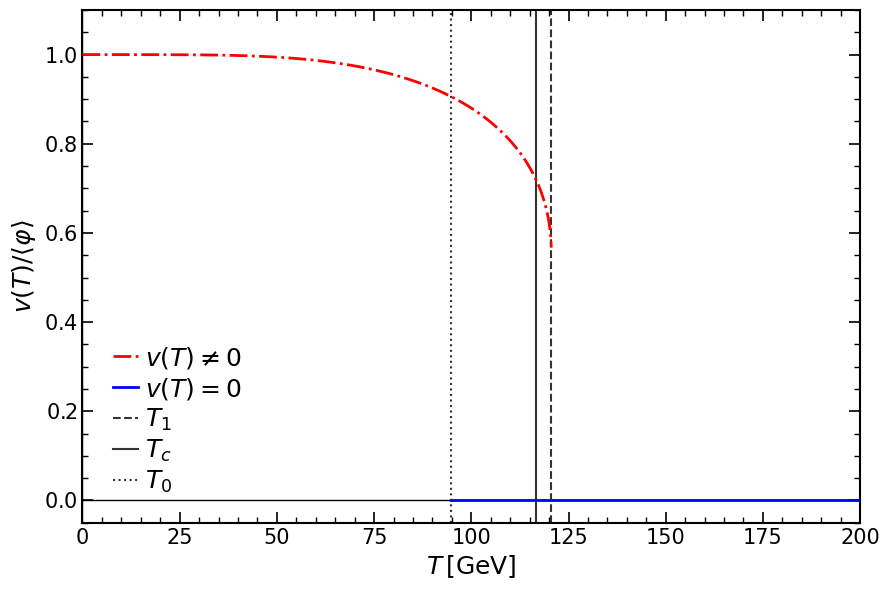

In [6]:
T_sym = phases[1].T
X_sym = phases[1].X

T_brk = phases[0].T
X_brk = phases[0].X

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(T_brk, X_brk/X_brk[0], label=r'$v(T)\neq 0$', color='r', lw=2, ls='-.', zorder=10)
ax.plot(T_sym, X_sym/X_brk[0], label=r'$v(T) = 0$', color='b', lw=2, ls='-', zorder=10)
ax.axvline(T_brk[-1], label=r'$T_1$', color='k', lw=1.5, ls='--', alpha=0.8)
ax.axvline(Tc, label=r'$T_c$', color='k', lw=1.5, ls='-', alpha=0.8)
ax.axvline(T_sym[0], label=r'$T_0$', color='k', lw=1.5, ls=':', alpha=0.8)

ax.set_xlim(0, 200)
ax.set_ylim(-0.05, 1.1)

ax.set_xlabel(r'$T \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$v(T)/\langle\varphi\rangle$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
#ax.tick_params(axis='x', which='major', pad=8)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"AHM_Thermal_VEV.pdf", format="pdf", bbox_inches="tight")
plt.show()